# Import Libraries

In [19]:
import sys
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import sys  # Used in process_single_run to suppress game-by-game output
from io import StringIO # Used in process_single_run to suppress game-by-game output
import warnings
from requests.exceptions import RequestsDependencyWarning
from typing import List, Optional

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Custom imports from the project
from common.utils import load_config, setup_environment_and_agent, generate_video, find_checkpoints
from evaluate import play_one_game, evaluate_agent, calculate_summary_stats

# Configure for high quality plots
%matplotlib inline
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

# Suppress specific warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*You are using `torch.load`.*")
warnings.filterwarnings("ignore", category=RequestsDependencyWarning)
print("warnings configured")

warnings configured


# Helper Functions

In [20]:
def process_single_run(run_path: Path, num_eval_games: int, target_timesteps: Optional[List[int]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Processes a single experimental run folder, evaluates all its checkpoints,
    and returns the aggregated raw and summary data for that run.

    Parameters:
    - run_path (Path): Path to the run folder (e.g., models/dqn_run_01)
    - num_eval_games (int): Number of games to play per checkpoint for evaluation.
    - target_timesteps (Optional[List[int]]): If provided, only evaluate checkpoints at these timesteps.   

    Returns:
    - tuple: (raw_df, summary_df) DataFrames for this run.
        raw_df: Detailed game-by-game results for all checkpoints in this run.
        summary_df: Aggregated summary statistics per checkpoint in this run.
    """
    # Infer agent type and config path from the folder structure
    agent_type = run_path.parent.name.split('_')[0].lower()
    config_path = project_root / "configs" / f"{agent_type}_config.yaml"
    
    if not config_path.exists():
        print(f"  [!] Warning: Config file not found at {config_path}. Skipping run.")
        return pd.DataFrame(), pd.DataFrame()
        
    config = load_config(config_path)
    config['agent'] = agent_type
    
    # Collect all checkpoint paths
    checkpoint_paths = find_checkpoints(run_path)
    if not checkpoint_paths:
        print(f"  [!] Warning: No checkpoints found. Skipping run.")
        return pd.DataFrame(), pd.DataFrame()
    
    if target_timesteps:
        filtered_paths = []
        target_set = set(target_timesteps)
        for path in checkpoint_paths:
            match = re.search(r'step_(\d+)\.pth$', path.name)
            if match:
                timestep = int(match.group(1))
                if timestep in target_set:
                    filtered_paths.append(path)

        if not filtered_paths:
            print(f"  [!] Warning: No checkpoints matched target timesteps {target_timesteps}. Skipping run.")
            return pd.DataFrame(), pd.DataFrame()
        
        checkpoint_paths_to_process = filtered_paths

    else:
        checkpoint_paths_to_process = checkpoint_paths  # Use all found checkpoints
        
    # Setup environment and agent
    env, agent, device = setup_environment_and_agent(config)
    
    # Loop over checkpoints and evaluate
    all_checkpoints_summaries = []
    all_checkpoints_raw_data = []

    checkpoint_prog_bar = tqdm(checkpoint_paths_to_process, desc=f"Evaluating {run_path.name}", leave=False)
    for model_path in checkpoint_prog_bar:
        try:
            timestep = int(re.search(r'step_(\d+)\.pth$', model_path.name).group(1))
            checkpoint_prog_bar.set_postfix_str(f"t={timestep}")
            
            # Load model weights into the existing agent
            agent.load(str(model_path))

            raw_df_for_checkpoint = evaluate_agent(agent, env, num_games=num_eval_games, show_progress=False)

            # Calculate summary stats for this checkpoint
            summary_df_for_checkpoint = calculate_summary_stats(raw_df_for_checkpoint)
            
            # Add metadata for aggregation and plotting
            raw_df_for_checkpoint['timestep'] = timestep
            summary_df_for_checkpoint['timestep'] = timestep
            
            all_checkpoints_raw_data.append(raw_df_for_checkpoint)
            all_checkpoints_summaries.append(summary_df_for_checkpoint)

        except Exception as e:
            #sys.stdout = original_stdout  # Ensure we reset stdout on error
            print(f"  [!] Failed to evaluate checkpoint {model_path.name}. Error: {e}")
            
    env.close() # Close the env to free up resources

    if not all_checkpoints_summaries:
        print(f"  [!] No checkpoints were successfully evaluated for {run_path.name}.")
        return pd.DataFrame(), pd.DataFrame()
        
    # Combine all results for this single run
    run_raw_df = pd.concat(all_checkpoints_raw_data, ignore_index=True)
    run_summary_df = pd.concat(all_checkpoints_summaries, ignore_index=True)
    
    # Add run-level metadata
    run_raw_df['run_name'] = run_path.name
    run_summary_df['run_name'] = run_path.name
    run_raw_df['agent_type'] = agent_type
    run_summary_df['agent_type'] = agent_type
    
    return run_raw_df, run_summary_df

def run_full_analysis(base_models_dir: Path, num_eval_games: int, target_timesteps: Optional[List[int]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Orchestrates the entire analysis. Discovers all runs, processes them,
    and returns two master DataFrames with all results.

    Parameters:
    - base_models_dir (Path): Path to the base models directory (e.g., models
    - num_eval_games (int): Number of games to play per checkpoint for evaluation.
    - target_timesteps (Optional[List[int]]): If provided, only evaluate checkpoints at these timesteps.

    Returns:
    - tuple: (master_raw_df, master_summary_df)
        master_raw_df: Detailed game-by-game results for all runs and checkpoints.
        master_summary_df: Aggregated summary statistics per run and checkpoint.
    """

    # Discover all run folders
    run_paths = []
    agent_checkpoint_dirs = [p for p in base_models_dir.iterdir() if p.is_dir()]
    for agent_dir in agent_checkpoint_dirs:
        runs_in_dir = [p for p in agent_dir.iterdir() if p.is_dir() and not p.name.startswith('.')]
        run_paths.extend(runs_in_dir)
    run_paths.sort(key=lambda p: p.name)

    if not run_paths:
        print(f"No run folders found in {base_models_dir}. Analysis cannot proceed.")
        return pd.DataFrame(), pd.DataFrame()
    
    print(f"Found {len(run_paths)} total experiment runs to analyze.")
    
    # Process each run
    all_runs_raw = []
    all_runs_summaries = []
    
    for path in tqdm(run_paths, desc="Processing Runs"):
        raw_df, summary_df = process_single_run(run_path=path, num_eval_games=num_eval_games, target_timesteps=target_timesteps)
        if not raw_df.empty:
            all_runs_raw.append(raw_df)
            all_runs_summaries.append(summary_df)
            
    # Final aggregation
    if not all_runs_raw:
        print("\n\nNo data was successfully processed. Master DataFrames will be empty.")
        return pd.DataFrame(), pd.DataFrame()
        
    master_raw_df = pd.concat(all_runs_raw, ignore_index=True)
    master_summary_df = pd.concat(all_runs_summaries, ignore_index=True)
    
    print("\n\nFull analysis complete. Master DataFrames are ready.")
    return master_raw_df, master_summary_df

In [21]:
def plot_comparative_learning_curves(master_summary_df: pd.DataFrame, num_eval_games: int) -> None:
    """
    Plots comparative learning curves for all runs in the master summary DataFrame.

    Parameters:
    - master_summary_df (DataFrame): Aggregated summary statistics for all runs.
    - num_eval_games (int): Number of evaluation games used to compute mean scores.

    Returns:
    - None (displays the plot)
    """
    if master_summary_df.empty:
        print("Master summary DataFrame is empty. Cannot plot learning curves.")
        return

    print("\nGenerating comparative learning curves...")
    g = sns.relplot(
        data=master_summary_df,
        x="timestep",
        y="mean_score",
        hue="run_name",
        col="agent_type",
        kind="line",
        marker="o",
        height=7,
        aspect=1.5,
        facet_kws={'sharey': False, 'sharex': True},
    )

    # Add error bands for standard deviation
    for agent_type, ax in g.axes_dict.items():
        agent_df = master_summary_df[master_summary_df['agent_type'] == agent_type]
        for run_name in agent_df['run_name'].unique():
            run_data = agent_df[agent_df['run_name'] == run_name]
            ax.fill_between(
                run_data['timestep'],
                run_data['mean_score'] - run_data['std_score'],
                run_data['mean_score'] + run_data['std_score'],
                alpha=0.2,
            )

    # Customize legend
    legend = g.legend
    if legend: # Check if a legend exists before trying to modify it
        legend.set(title="Experimental Runs", loc='upper left', bbox_to_anchor=(0.10, 0.95), frame_on=True)
        legend.get_frame().set_facecolor('white') # Set the background color
        legend.get_frame().set_edgecolor('black') # Set the border color


    # Add titles and labels
    g.figure.suptitle("Comparative Learning Curves: Mean Score vs. Training Steps", y=1.03, fontsize=16)
    g.set_axis_labels("Training Timesteps", f"Mean Score (over {num_eval_games} games)")
    g.set_titles("Agent: {col_name}")
    plt.tight_layout(pad=0.1)

    plt.show()

def plot_final_box_whisker(master_raw_df: pd.DataFrame, master_summary_df: pd.DataFrame, num_eval_games: int) -> None:
    """
    Plots box-and-whisker plots of final evaluation scores for each run.

    Parameters:
    - master_raw_df (DataFrame): Detailed game-by-game results for all runs.
    - master_summary_df (DataFrame): Aggregated summary statistics for all runs.
    - num_eval_games (int): Number of evaluation games used to compute mean scores.

    Returns:
    - None (displays the plot)
    """
    print("\nGenerating final box-and-whisker plots...")

    last_timestep_df = master_summary_df.loc[master_summary_df.groupby('run_name')['timestep'].idxmax()]
    final_raw_df = master_raw_df[master_raw_df['timestep'].isin(last_timestep_df['timestep'])]

    plt.figure(figsize=(12, 7))

    sns.boxplot(
        data=final_raw_df,
        x='run_name',
        y='score',
        hue='agent_type',
        palette='colorblind',
    )

    plt.title(f'Final Evaluation Score Distribution (over {num_eval_games} games)', fontsize=16)
    plt.xlabel('Experimental Runs', fontsize=12)
    plt.ylabel(f'Score (over {num_eval_games})', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Agent Type', loc='upper right')

    plt.tight_layout()

    plt.show()


# Run Configuration

In [ ]:
TARGET_START_TIMESTEPS = 8000000  # Default start timestep for analysis
TARGET_END_TIMESTEPS = 40000000    # Default end timestep for analysis
TARGET_STEPSIZES = 1000000  # Default step size for analysis
TARGET_TIMESTEPS = range(TARGET_START_TIMESTEPS, TARGET_END_TIMESTEPS+1, TARGET_STEPSIZES)  # Default target timesteps from 8M to 40M in increments of 1M

# Configure paths and parameters
MODELS_DIR = project_root / "models"
NUM_EVAL_GAMES = 100 # Use a small number for testing, increase for final analysis (e.g., 100)

# Run the full analysis
master_raw_df, master_summary_df = run_full_analysis(
    base_models_dir=MODELS_DIR,
    num_eval_games=NUM_EVAL_GAMES,
    target_timesteps=TARGET_TIMESTEPS
)

# Check the output
if not master_summary_df.empty:
    print("\n--- Master Summary DataFrame ---")
    display(master_summary_df.head())
    print("\n--- Unique Runs Analyzed ---")
    print(master_summary_df['run_name'].unique())

Found 3 total experiment runs to analyze.


Processing Runs:   0%|          | 0/3 [00:00<?, ?it/s]

Searching for checkpoints in: g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\Archive
  [!] Warning: No checkpoints found. Skipping run.
Searching for checkpoints in: g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\Archive
  [!] Warning: No checkpoints found. Skipping run.
Searching for checkpoints in: g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\PPO_Run_12
Using device: cuda
Environment created and wrapped with unified AtariWrapper.
PPO Agent instantiated.


Evaluating PPO_Run_12:   0%|          | 0/23 [00:00<?, ?it/s]

Loading checkpoint from g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\PPO_Run_12\ppo_model_step_8000000.pth...
Loaded new-style checkpoint. Resuming from timestep 8000000.
Loading checkpoint from g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\PPO_Run_12\ppo_model_step_9000000.pth...
Loaded new-style checkpoint. Resuming from timestep 9000000.
Loading checkpoint from g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\PPO_Run_12\ppo_model_step_10000000.pth...
Loaded new-style checkpoint. Resuming from timestep 10000000.
Loading checkpoint from g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\PPO_Run_12\ppo_model_step_11000000.pth...
Loaded new-style checkpoint. Resuming from timestep 11000000.
Loading checkpoint from g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\PPO_Run_12\ppo_model_step_12000000.pth...
Loaded new-style checkpoint. Resuming from timestep 12000000.
Loading checkpoint from g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\PPO_Run_12\ppo_model_step_13000000.pth...
Load

,mean_score,std_score,min_score,Q1_score,Median_score,Q3_score,max_score,mean_steps,std_steps,level_1_completion_rate,mean_level_reached,max_level_reached,timestep,run_name,agent_type
0,1297.5,301.991287,640.0,910.0,1510.0,1510.0,1510.0,799.90,152.833276,0.0,0.0,0,8000000,PPO_Run_12,ppo
1,2060.0,0.000000,2060.0,2060.0,2060.0,2060.0,2060.0,658.76,1.688464,0.0,0.0,0,9000000,PPO_Run_12,ppo
2,2130.0,0.000000,2130.0,2130.0,2130.0,2130.0,2130.0,683.00,0.000000,0.0,0.0,0,10000000,PPO_Run_12,ppo
3,2863.7,302.226268,2450.0,2610.0,2770.0,3230.0,3320.0,977.02,69.886196,0.0,0.0,0,11000000,PPO_Run_12,ppo
4,2674.6,99.406522,2490.0,2607.5,2660.0,2722.5,3080.0,923.94,115.102573,0.0,0.0,0,12000000,PPO_Run_12,ppo



--- Unique Runs Analyzed ---
['PPO_Run_12']


In [23]:
print(master_summary_df.head(20))

    mean_score   std_score  min_score  Q1_score  Median_score  Q3_score  \
0       1297.5  301.991287      640.0     910.0        1510.0    1510.0   
1       2060.0    0.000000     2060.0    2060.0        2060.0    2060.0   
2       2130.0    0.000000     2130.0    2130.0        2130.0    2130.0   
3       2863.7  302.226268     2450.0    2610.0        2770.0    3230.0   
4       2674.6   99.406522     2490.0    2607.5        2660.0    2722.5   
5       3166.1  522.168932     2450.0    2670.0        3040.0    3930.0   
6       1801.9  206.723819     1400.0    1910.0        1910.0    1910.0   
7       1705.8  254.527409     1230.0    1640.0        1650.0    1872.5   
8        562.4   93.009395      520.0     520.0         520.0     520.0   
9       1068.6   84.554925      540.0    1070.0        1070.0    1090.0   
10      1158.9   31.810519      870.0    1160.0        1160.0    1160.0   
11      1508.4   19.107352     1440.0    1480.0        1520.0    1520.0   
12      1488.8  100.81766


Generating comparative learning curves...


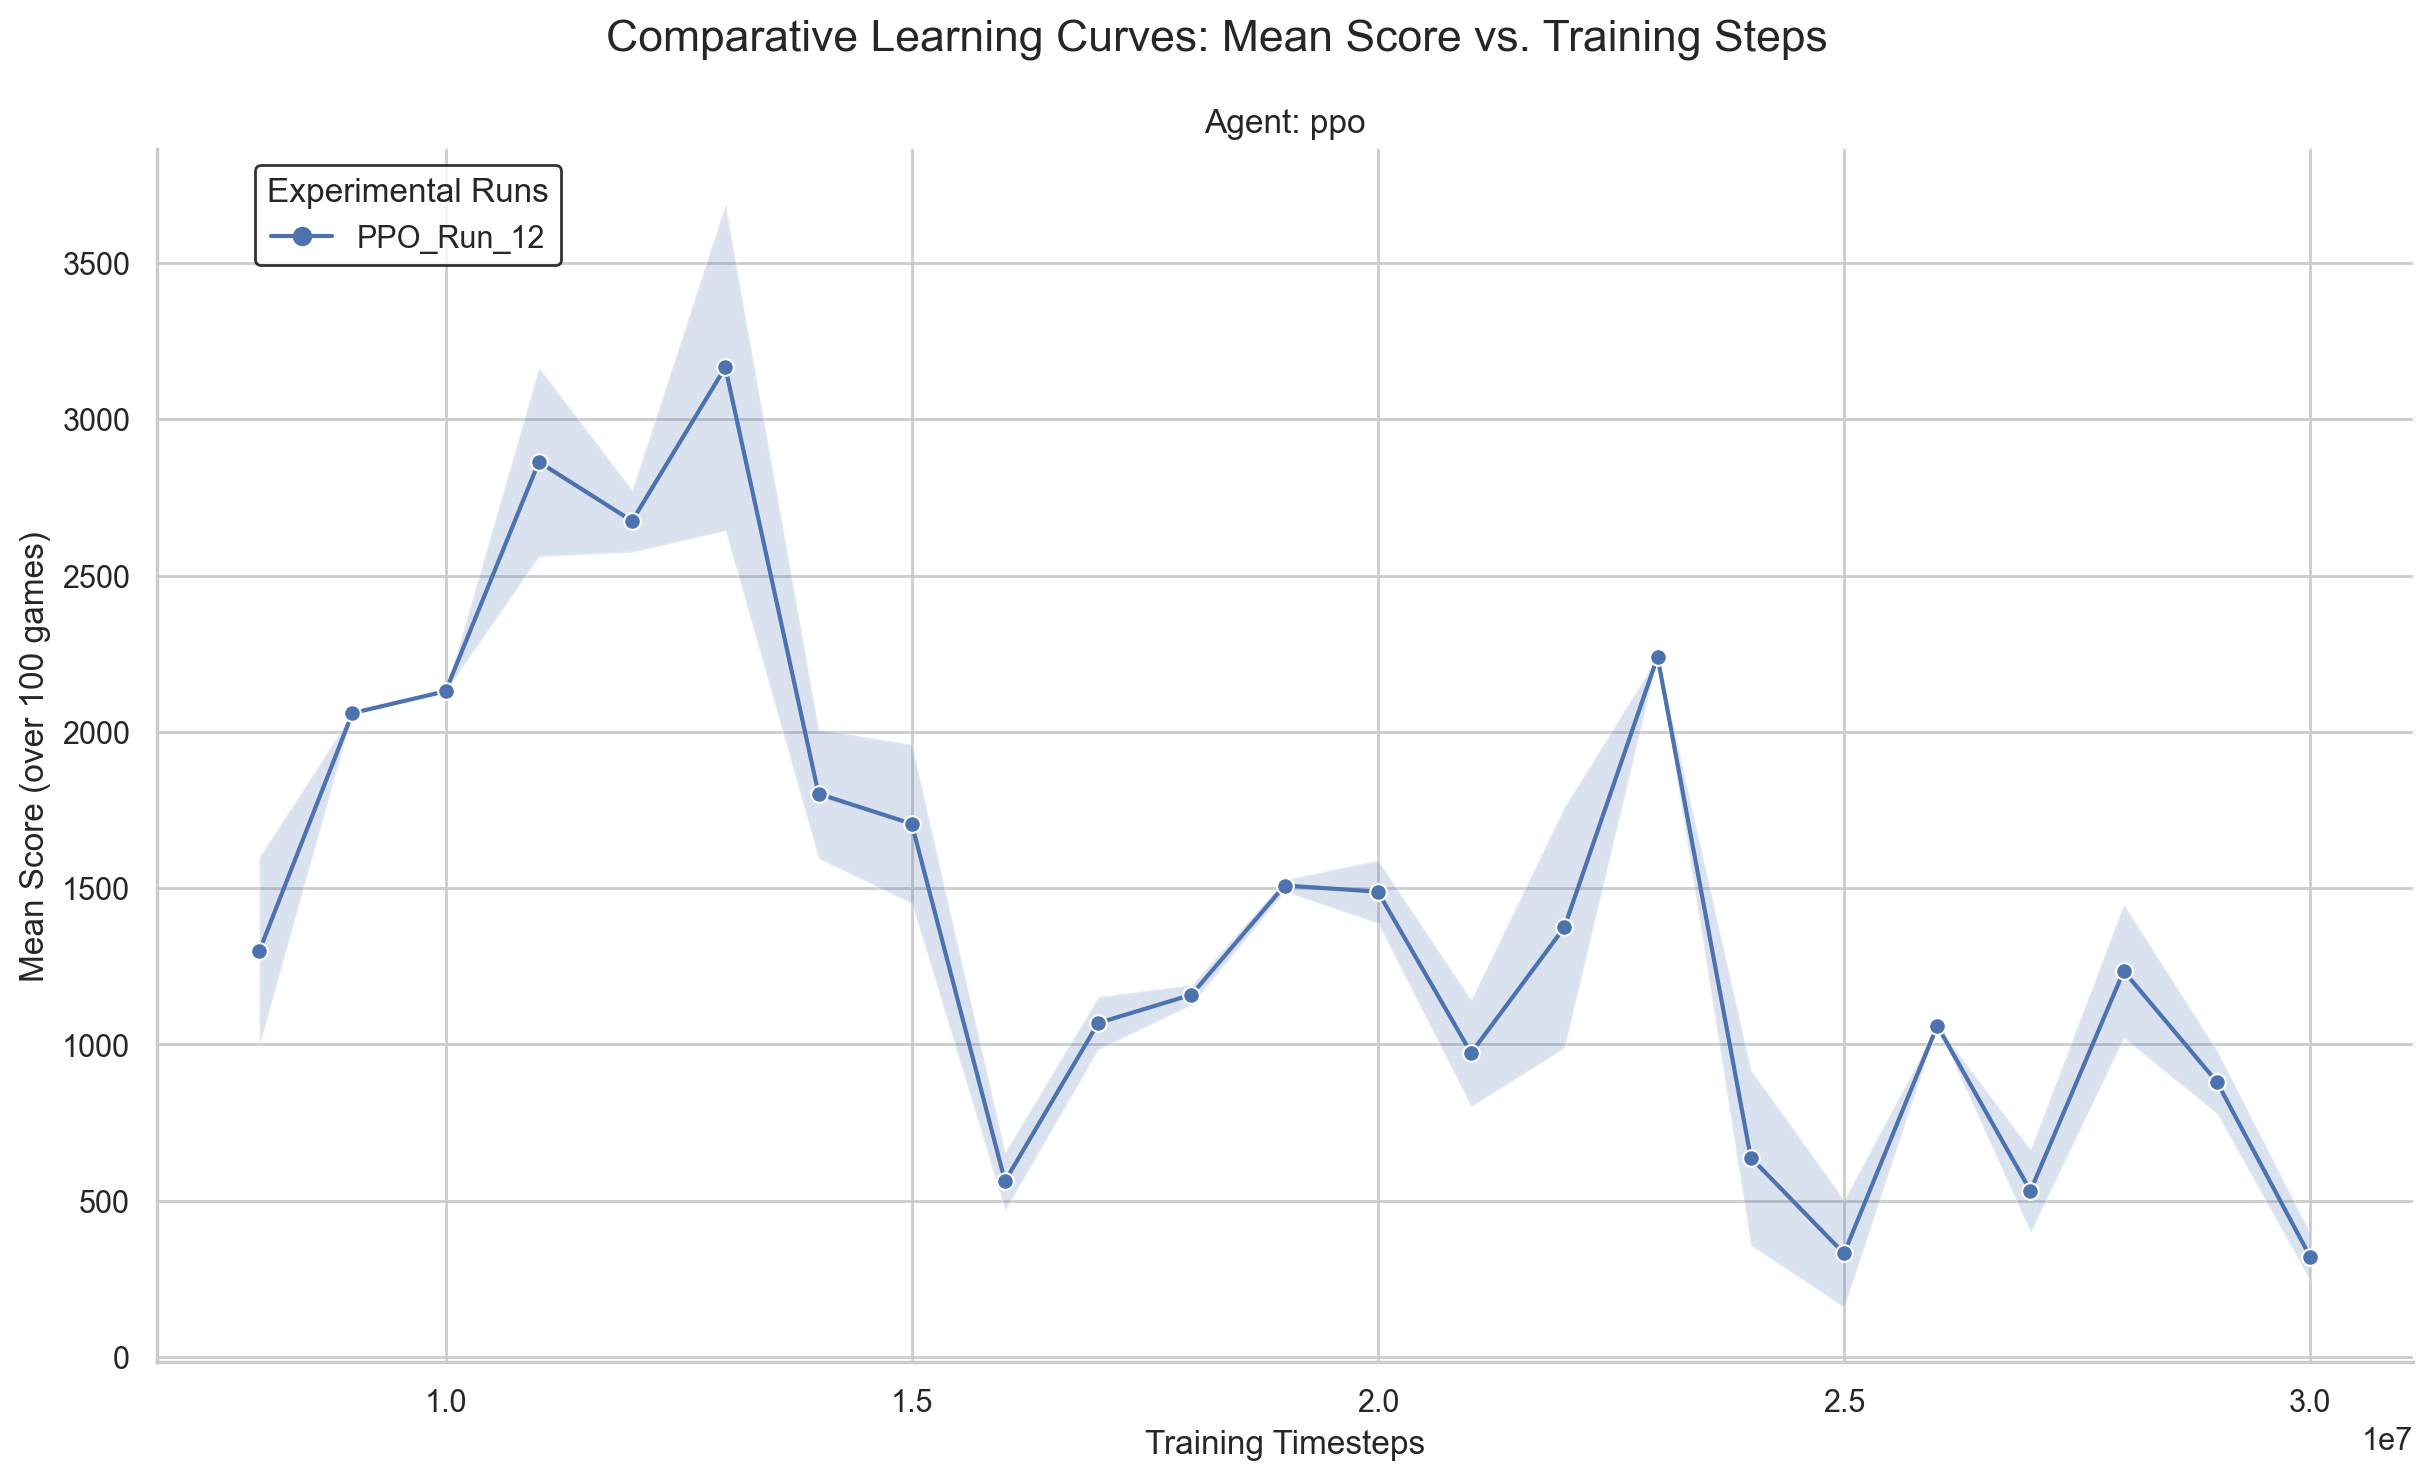


Generating final box-and-whisker plots...


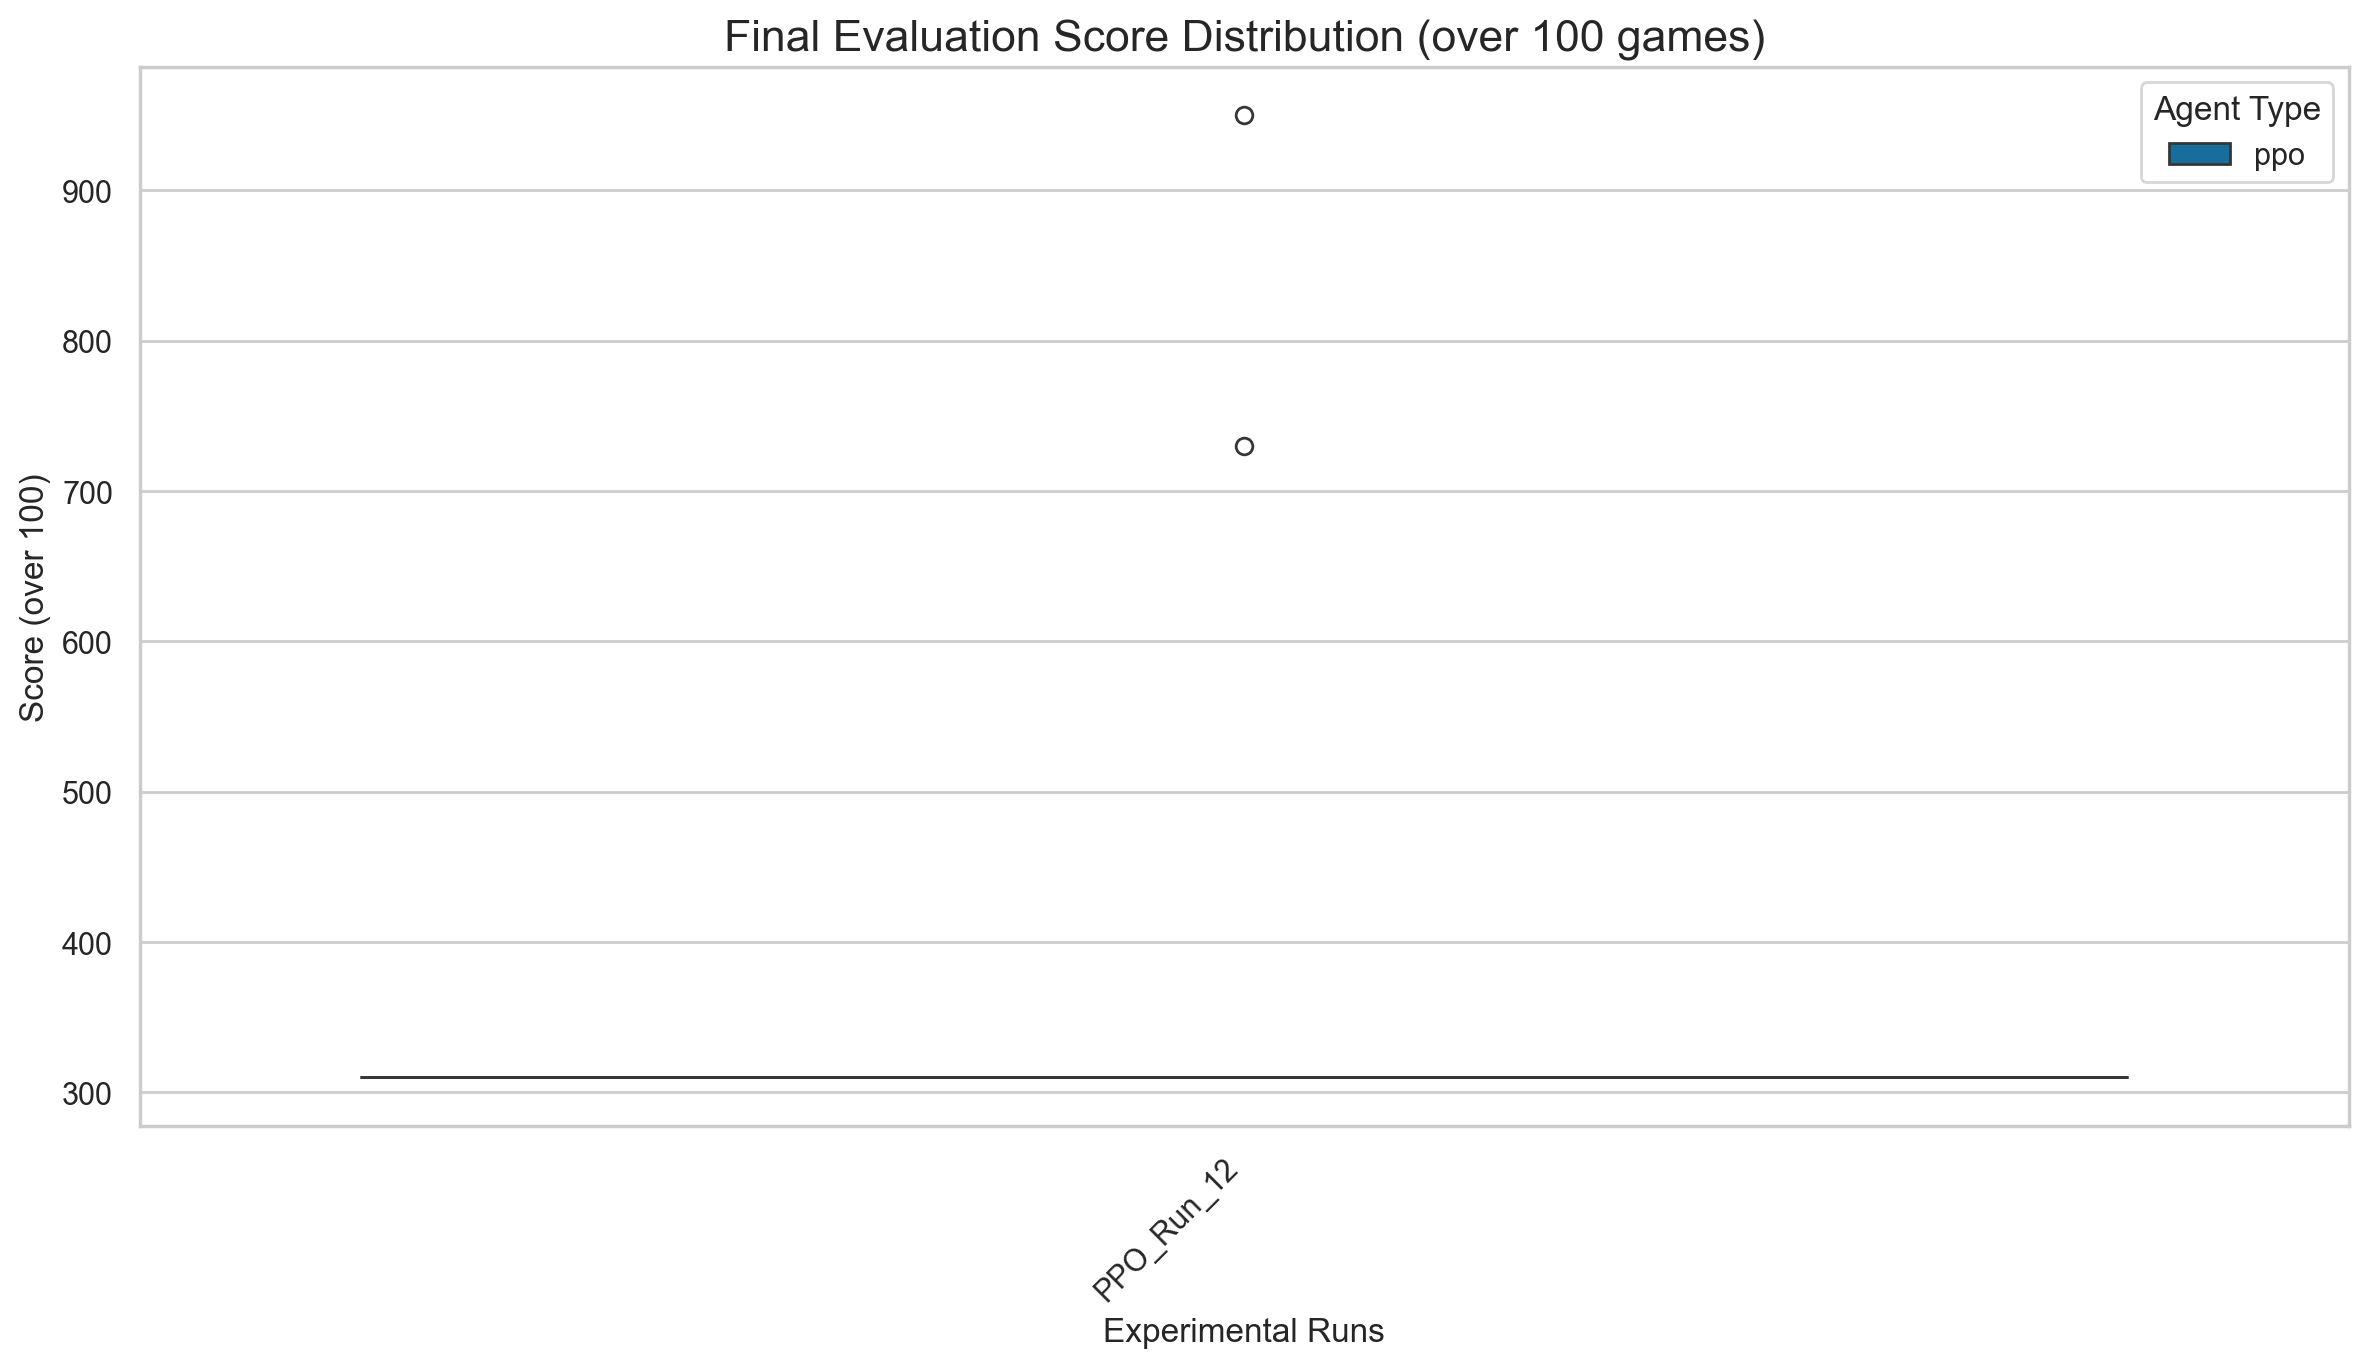

In [24]:
plot_comparative_learning_curves(master_summary_df=master_summary_df, num_eval_games=NUM_EVAL_GAMES)
plot_final_box_whisker(master_raw_df=master_raw_df, master_summary_df=master_summary_df, num_eval_games=NUM_EVAL_GAMES)

Master summary DataFrame is empty. Cannot plot learning curves.

Generating comparative learning curves...


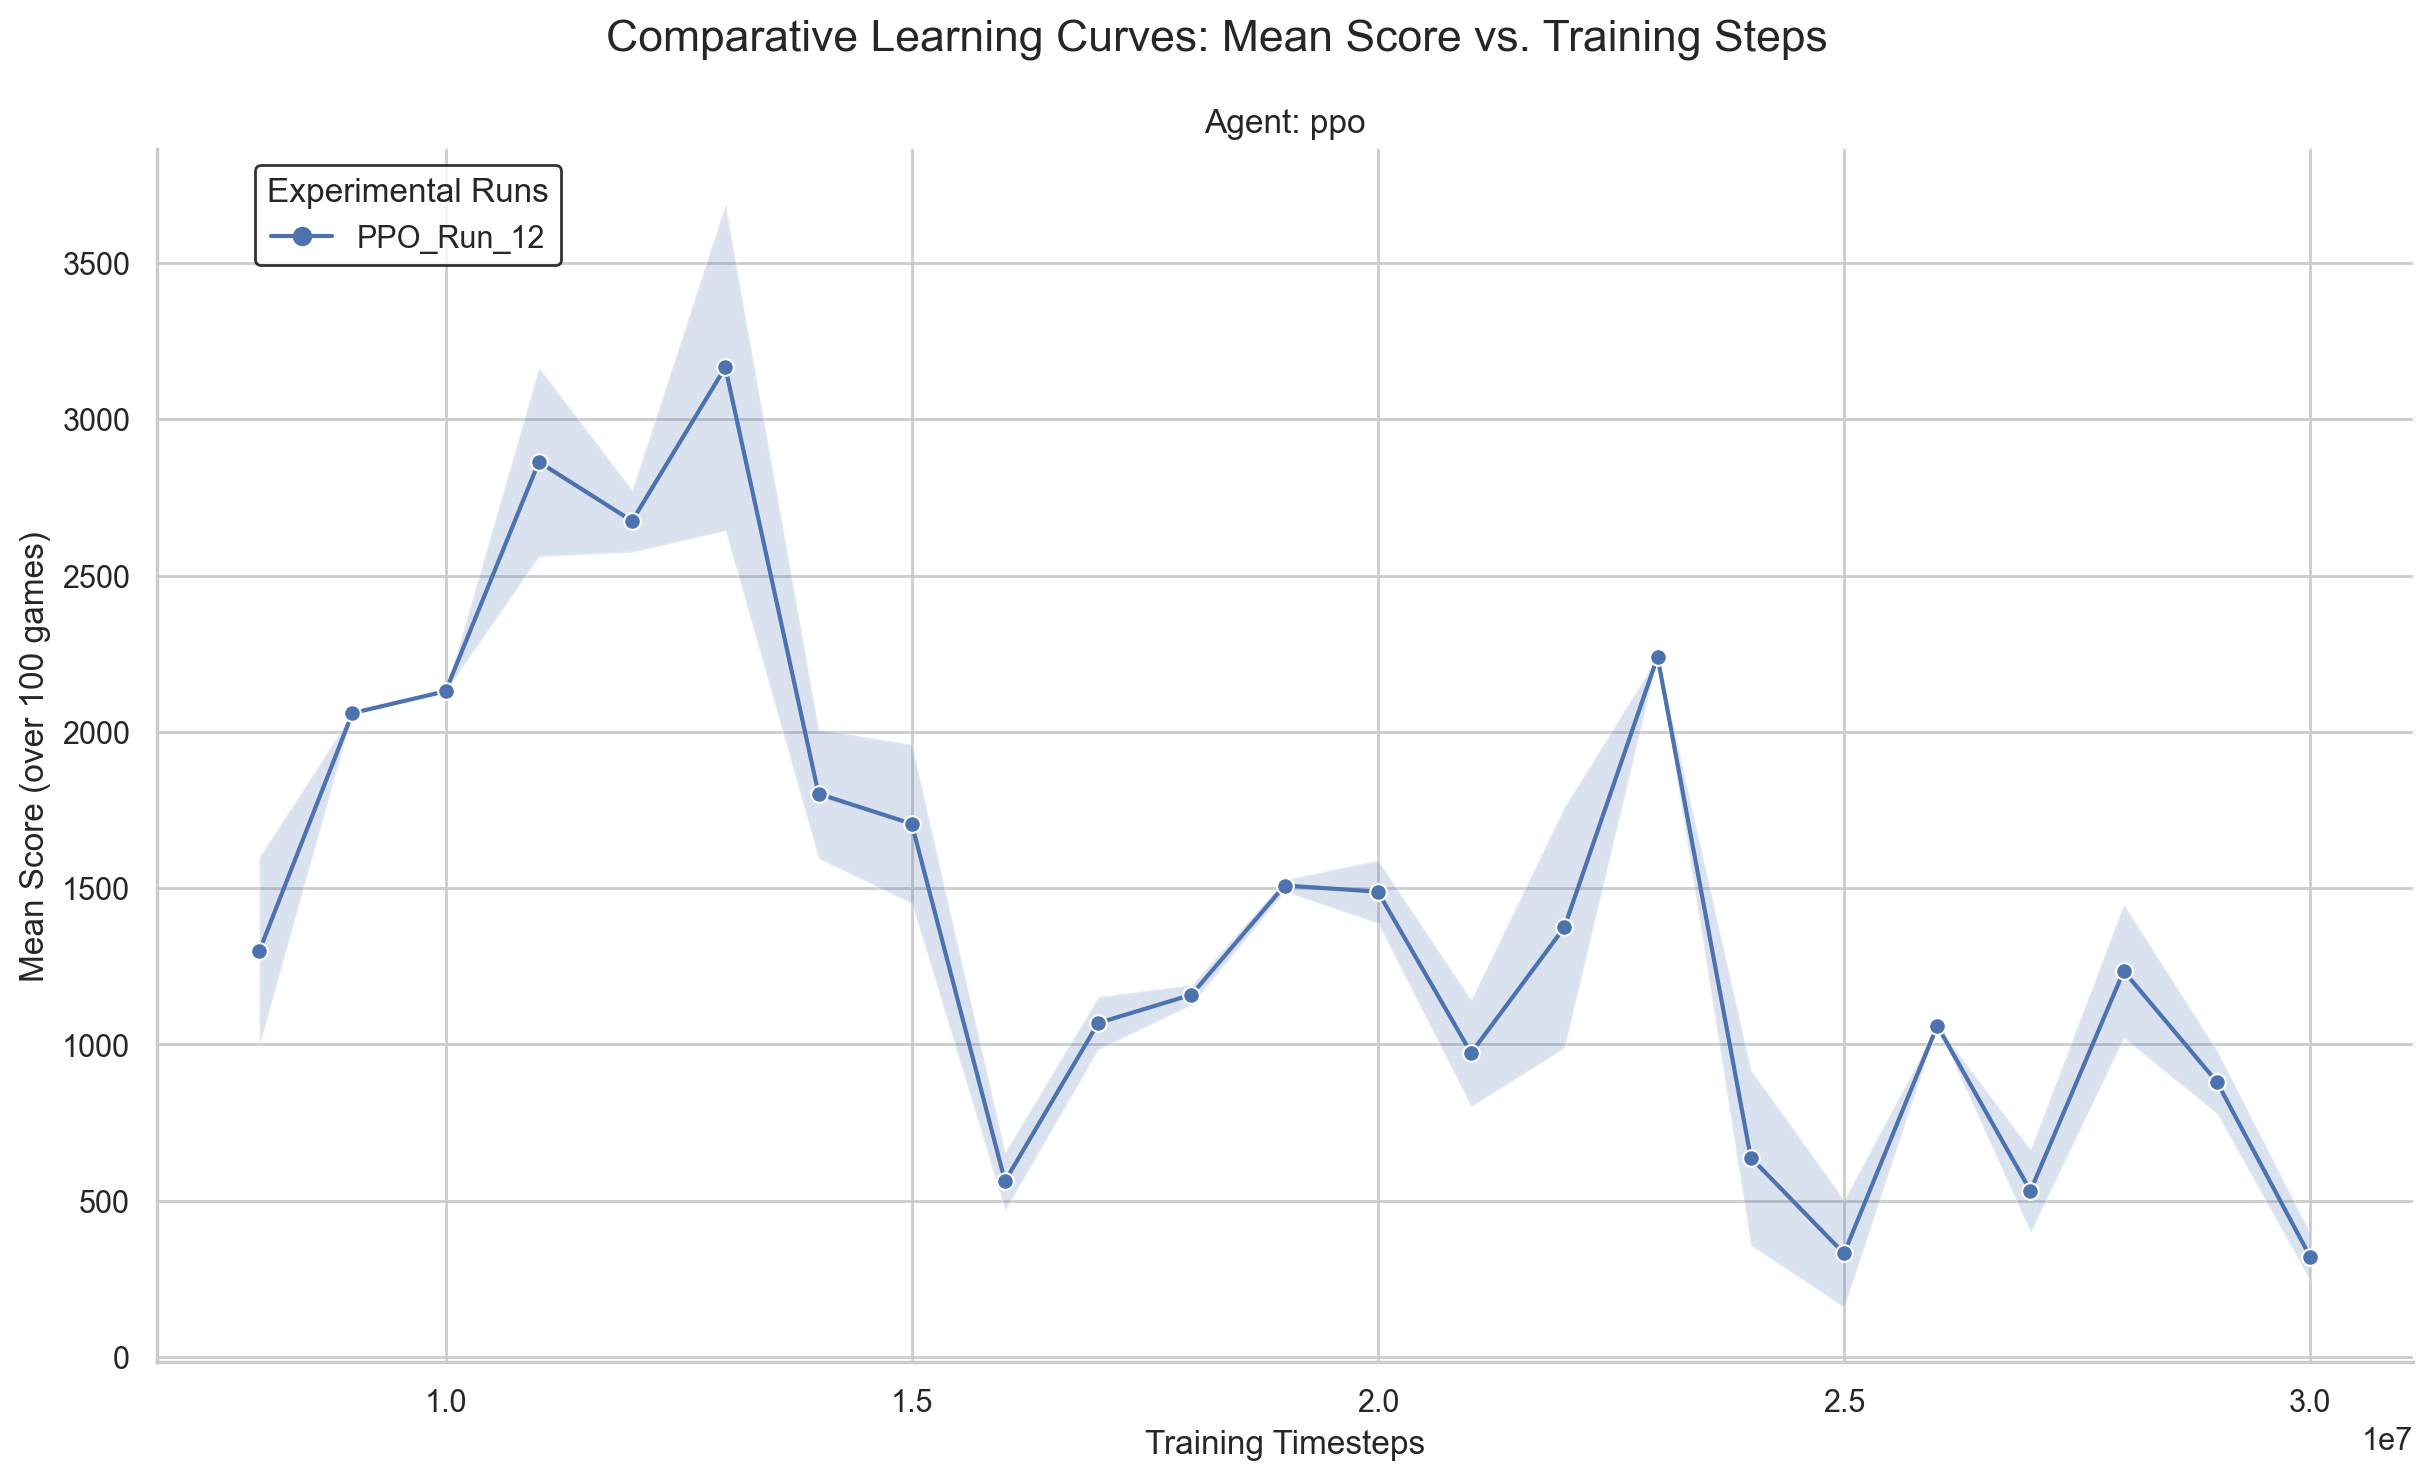

In [25]:
dqn_master_summary_df = master_summary_df[master_summary_df['agent_type'] == 'dqn']
ppo_master_summary_df = master_summary_df[master_summary_df['agent_type'] == 'ppo']
plot_comparative_learning_curves(master_summary_df=dqn_master_summary_df, num_eval_games=NUM_EVAL_GAMES)
plot_comparative_learning_curves(master_summary_df=ppo_master_summary_df, num_eval_games=NUM_EVAL_GAMES)

# Output dataset to CSV

In [26]:
# Output dataset to CSV
csv_filename = project_root / "evaluation_results.csv"
master_summary_df.to_csv(csv_filename, index=False)
print(f"\nMaster summary DataFrame saved to {csv_filename}")


Master summary DataFrame saved to g:\Github\DeepRL-MsPacman\evaluation_results.csv


# Create play video

In [27]:
print("--- Running Video Generation Test ---")

# User configuration for video generation test
# Specify the agent type, run name, and checkpoint timestep to test.
AGENT_TYPE_TO_TEST = 'dqn'
RUN_NAME_TO_TEST = 'DQN_Run_1'
TIMESTEP_TO_TEST = 10000000 # e.g., for '..._step_10000000.pth'

# Specify a custom, clean name for the output video file.
VIDEO_FILENAME = f"{RUN_NAME_TO_TEST}_step_{TIMESTEP_TO_TEST}_gameplay"
# --- End Configuration ---

try:
    generate_video(
        agent_type=AGENT_TYPE_TO_TEST,
        run_name=RUN_NAME_TO_TEST,
        checkpoint_timestep=TIMESTEP_TO_TEST,
        video_filename=VIDEO_FILENAME
    )
    print("\nTest completed successfully.")
except FileNotFoundError as e:
    print(f"\nTest failed: {e}")
    print("Please ensure the AGENT_TYPE, RUN_NAME, and TIMESTEP variables match your saved files.")
except Exception as e:
    print(f"\nAn unexpected error occurred during the test: {e}")



--- Running Video Generation Test ---
--- Generating video for DQN_Run_1 at timestep 10000000 ---
Using device: cuda
Environment created and wrapped with unified AtariWrapper.
DQN Agent instantiated.

Test failed: Checkpoint for timestep 10000000 not found in g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1
Please ensure the AGENT_TYPE, RUN_NAME, and TIMESTEP variables match your saved files.
